# Prashun Kafle

# Deliverable 4  Final Project

## 1. Problem Statement

### The goal of this project is to build a predictive model that estimates the number of U.S. land border crossings (Value) at various ports of entry. Using features such as port location (Latitude, Longitude), border type (Border), crossing category (Measure), and date-derived information (Year, Month), we aim to identify patterns and produce reliable crossing-volume predictions. Accurate predictions can assist in resource planning, staffing, and policy decisions at border checkpoints.

## 2. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')


## 3. Load and Prepare Cleaned Data

### We reload the original dataset and apply the same cleaning pipeline from Deliverable 2 to ensure the data is ready for modeling.

In [2]:
# Load raw dataset
df = pd.read_csv('Border_Crossing_Entry_Data.csv')

# Drop the Point column (duplicates lat/lon)
df.drop(columns=['Point'], errors='ignore', inplace=True)

# Fill missing State values
df['State'].fillna('Unknown', inplace=True)

# Filling in missing Latitude / Longitude with median
df['Latitude'].fillna(df['Latitude'].median(), inplace=True)
df['Longitude'].fillna(df['Longitude'].median(), inplace=True)

# Convert Date to Year and Month
df['Date'] = pd.to_datetime(df['Date'], format='%b %Y') #CHAT helped with this to make it more efficient
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Remove duplicates
df.drop_duplicates(inplace=True)

# Strip whitespace from text columns
for col in ['Port Name', 'Measure', 'Border', 'State']:
    df[col] = df[col].str.strip()

print('Dataset shape after cleaning:', df.shape)
df.head()

Dataset shape after cleaning: (406710, 11)


,Port Name,State,Port Code,Border,Date,Measure,Value,Latitude,Longitude,Year,Month
0,Jackman,Maine,104,US-Canada Border,2024-01-01,Trucks,6556,45.806,-70.397,2024,1
1,Porthill,Idaho,3308,US-Canada Border,2024-04-01,Trucks,98,49.000,-116.499,2024,4
2,San Luis,Arizona,2608,US-Mexico Border,2024-04-01,Buses,10,32.485,-114.782,2024,4
3,Willow Creek,Montana,3325,US-Canada Border,2024-01-01,Pedestrians,2,49.000,-109.731,2024,1
4,Warroad,Minnesota,3423,US-Canada Border,2024-01-01,Personal Vehicle Passengers,9266,48.999,-95.377,2024,1


## 4. Feature Engineering

### We encode categorical variables using Label Encoding so that all features are numeric before feeding them into our models.

In [3]:
#categorical columns

#Asked CHATGPT to give me suggestions and it suggested to use Label Encoding for the categorical columns. I have implemented that in the code below.

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = ['Port Name', 'State', 'Border', 'Measure']

for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col])

# Sort by series so lag features use only past rows
df = df.sort_values(['Port Name', 'Measure', 'Date']).copy()

# Group by route/type combination
grp = df.groupby(['Port Name', 'Measure'])

# Time-series features
df['lag_1'] = grp['Value'].shift(1)
df['lag_3'] = grp['Value'].shift(3)

df['rolling_mean_3'] = grp['Value'].transform(
    lambda s: s.shift(1).rolling(window=3, min_periods=1).mean()
)

df['rolling_mean_6'] = grp['Value'].transform(
    lambda s: s.shift(1).rolling(window=6, min_periods=1).mean()
)

df['rolling_std_3'] = grp['Value'].transform(
    lambda s: s.shift(1).rolling(window=3, min_periods=1).std()
)

df['diff_1'] = df['lag_1'] - df['lag_3']
df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Fill rolling std NaN values created for very early rows
df['rolling_std_3'] = df['rolling_std_3'].fillna(0)

# Drop rows where lag values do not exist yet
df = df.dropna(subset=['lag_1', 'lag_3', 'rolling_mean_3', 'rolling_mean_6', 'diff_1']).copy()

# Define feature set and target
features = [
    'Port Name_enc', 'State_enc', 'Port Code',
    'Border_enc', 'Measure_enc',
    'Latitude', 'Longitude',
    'Year', 'Month',
    'month_sin', 'month_cos',
    'lag_1', 'lag_3',
    'rolling_mean_3', 'rolling_mean_6',
    'rolling_std_3', 'diff_1'
]

target = 'Value'

X = df[features]
y = df[target]

print("Dataset shape after time-series feature engineering:", df.shape)
df[features + [target]].head()

Dataset shape after time-series feature engineering: (402604, 23)


,Port Name_enc,State_enc,Port Code,Border_enc,Measure_enc,Latitude,Longitude,Year,Month,month_sin,month_cos,lag_1,lag_3,rolling_mean_3,rolling_mean_6,rolling_std_3,diff_1,Value
384325,2,0,3104,0,0,62.615,-141.001,1996,4,8.660254e-01,-0.500000,11.0,9.0,6.666667,6.666667,5.859465,2.0,17
365347,2,0,3104,0,0,62.615,-141.001,1996,5,5.000000e-01,-0.866025,17.0,0.0,9.333333,9.250000,8.621678,17.0,638
389532,2,0,3104,0,0,62.615,-141.001,1996,6,1.224647e-16,-1.000000,638.0,11.0,222.000000,135.000000,360.279059,627.0,5500
379092,2,0,3104,0,0,62.615,-141.001,1996,7,-5.000000e-01,-0.866025,5500.0,17.0,2051.666667,1029.166667,3002.442728,5483.0,6392
384618,2,0,3104,0,0,62.615,-141.001,1996,8,-8.660254e-01,-0.500000,6392.0,638.0,4176.666667,2093.000000,3096.859269,5754.0,6112


In [4]:
# Time-based split: train on earlier data, test on later data
split_date = pd.Timestamp('2023-01-01')

train_df = df[df['Date'] < split_date].copy()
test_df  = df[df['Date'] >= split_date].copy()

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print("Train date range:", train_df['Date'].min(), "to", train_df['Date'].max())
print("Test date range :", test_df['Date'].min(), "to", test_df['Date'].max())

Training samples: 375626
Test samples: 26978
Train date range: 1996-04-01 00:00:00 to 2022-12-01 00:00:00
Test date range : 2023-01-01 00:00:00 to 2025-12-01 00:00:00


## 5. Modeling Approaches

### We evaluate three regression models of increasing complexity to predict the number of border crossings *Value*. For each model we report:
- **RMSE** (Root Mean Squared Error) — penalizes large errors
- **MAE** (Mean Absolute Error) — average magnitude of errors
- **R²** (Coefficient of Determination) — proportion of variance explained

### 5.1 Model 1 — Linear Regression (Baseline)

#### Linear Regression serves as our baseline. It assumes a linear relationship between the features and the target variable. While it is the simplest model, it gives us a reference point to measure the improvement of more complex models.

In [5]:
# Scale features for Linear Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print('Linear Regression')
print(f' RMSE : {rmse_lr:,.2f}')
print(f' MAE : {mae_lr:,.2f}')
print(f' R²  : {r2_lr:.4f}')

Linear Regression
 RMSE : 16,092.14
 MAE : 4,077.66
 R²  : 0.9874


### 5.2 Model 2 — Random Forest Regressor

#### Random Forest is an ensemble of decision trees that captures non-linear relationships and feature interactions. It is more powerful than Linear Regression and provides feature importance rankings, giving interpretability alongside improved accuracy.

Random Forest Regressor
 RMSE : 14,031.79
 MAE  : 2,864.91
 R²   : 0.9904


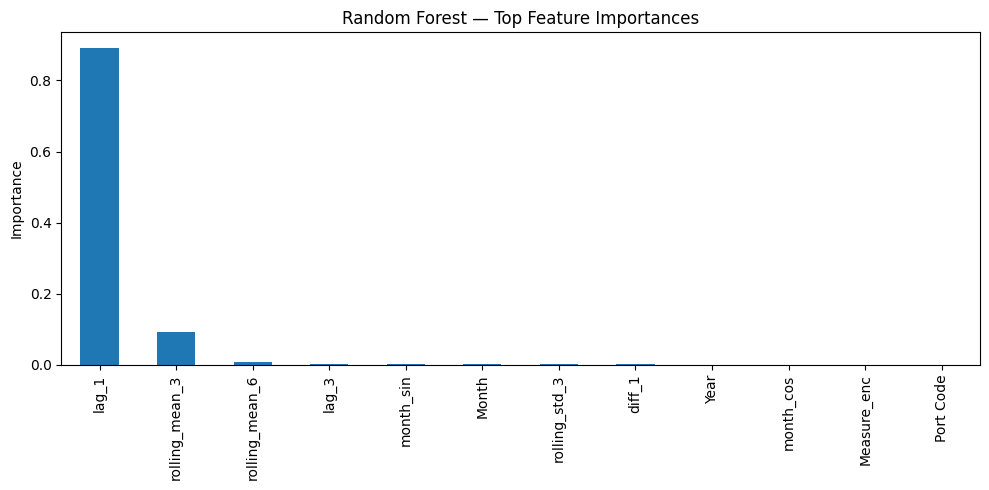

In [6]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print('Random Forest Regressor')
print(f' RMSE : {rmse_rf:,.2f}')
print(f' MAE  : {mae_rf:,.2f}')
print(f' R²   : {r2_rf:.4f}')

# Feature importance plot
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.head(12).plot(kind='bar')
plt.title('Random Forest — Top Feature Importances')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

### 5.3 Model 3 — Histogram Gradient Boosting Regressor

#### Histogram Gradient Boosting is a powerful sequential ensemble method that builds trees one at a time, with each tree correcting the errors of the previous ones. It is especially effective on large, complex datasets and natively handles missing values. We expect this to be our best-performing model.

In [7]:
hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_depth=8,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=42
)

hgb.fit(X_train, y_train)
y_pred_hgb = hgb.predict(X_test)

rmse_hgb = np.sqrt(mean_squared_error(y_test, y_pred_hgb))
mae_hgb  = mean_absolute_error(y_test, y_pred_hgb)
r2_hgb   = r2_score(y_test, y_pred_hgb)

print('Histogram Gradient Boosting Regressor')
print(f' RMSE : {rmse_hgb:,.2f}')
print(f' MAE  : {mae_hgb:,.2f}')
print(f' R²   : {r2_hgb:.4f}')

Histogram Gradient Boosting Regressor
 RMSE : 17,558.63
 MAE  : 3,680.34
 R²   : 0.9850


## 6. Hyperparameter Tuning

### We tune the two strongest models Random Forest and Histogram Gradient Boosting using Grid Search with and cross-validation for Random Forest and Randomized Search for HGB to efficiently explore a larger parameter space.

### 6.1 Random Forest — Grid Search

In [8]:
rf_configs = [
    {"name": "Run 1", "n_estimators": 40, "max_depth": 6,  "min_samples_split": 10, "min_samples_leaf": 4},
    {"name": "Run 2", "n_estimators": 75, "max_depth": 12, "min_samples_split": 5,  "min_samples_leaf": 2},
    {"name": "Run 3", "n_estimators": 100, "max_depth": 18, "min_samples_split": 3, "min_samples_leaf": 1},
]

results = []
best_model = None
best_rmse = float("inf")
best_config = None

for config in rf_configs:
    rf = RandomForestRegressor(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_split=config["min_samples_split"],
        min_samples_leaf=config["min_samples_leaf"],
        random_state=42,
        n_jobs=1
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Run": config["name"],
        "n_estimators": config["n_estimators"],
        "max_depth": config["max_depth"],
        "min_samples_split": config["min_samples_split"],
        "min_samples_leaf": config["min_samples_leaf"],
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    if rmse < best_rmse:
        best_rmse = rmse
        best_model = rf
        best_config = config

results_df = pd.DataFrame(results).sort_values(by="RMSE").reset_index(drop=True)

print(results_df)
print("\nBest model based on RMSE:")
print(results_df.iloc[0])

     Run  n_estimators  max_depth  min_samples_split  min_samples_leaf  \
0  Run 2            75         12                  5                 2   
1  Run 3           100         18                  3                 1   
2  Run 1            40          6                 10                 4   

           RMSE          MAE        R2  
0  14087.371083  2967.027658  0.990364  
1  14176.964342  2864.176686  0.990241  
2  16406.284601  3752.803515  0.986931  

Best model based on RMSE:
Run                         Run 2
n_estimators                   75
max_depth                      12
min_samples_split               5
min_samples_leaf                2
RMSE                 14087.371083
MAE                   2967.027658
R2                       0.990364
Name: 0, dtype: object


### 6.2 Histogram Gradient Boosting — Randomized Search

In [9]:

results_df = pd.DataFrame(results).sort_values(by="RMSE")
print(results_df)

print("\nBest model based on RMSE:")
print(results_df.iloc[0])

     Run  n_estimators  max_depth  min_samples_split  min_samples_leaf  \
1  Run 2            75         12                  5                 2   
2  Run 3           100         18                  3                 1   
0  Run 1            40          6                 10                 4   

           RMSE          MAE        R2  
1  14087.371083  2967.027658  0.990364  
2  14176.964342  2864.176686  0.990241  
0  16406.284601  3752.803515  0.986931  

Best model based on RMSE:
Run                         Run 2
n_estimators                   75
max_depth                      12
min_samples_split               5
min_samples_leaf                2
RMSE                 14087.371083
MAE                   2967.027658
R2                       0.990364
Name: 1, dtype: object


In [10]:
from scipy.stats import uniform, randint

hgb_param_dist = {
    'learning_rate'   : uniform(0.01, 0.2),
    'max_iter'        : randint(100, 500),
    'max_depth'       : randint(3, 10),
    'min_samples_leaf': randint(10, 50),
    'l2_regularization': uniform(0, 1)
}

hgb_rand = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_distributions=hgb_param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
hgb_rand.fit(X_train, y_train)

print('Best HGB parameters:', hgb_rand.best_params_)

# Evaluate tuned HGB
y_pred_hgb_tuned = hgb_rand.best_estimator_.predict(X_test)
rmse_hgb_t = np.sqrt(mean_squared_error(y_test, y_pred_hgb_tuned))
mae_hgb_t  = mean_absolute_error(y_test, y_pred_hgb_tuned)
r2_hgb_t   = r2_score(y_test, y_pred_hgb_tuned)

print(f'Tuned HGB  RMSE: {rmse_hgb_t:,.2f}  |  MAE: {mae_hgb_t:,.2f}  |  R²: {r2_hgb_t:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best HGB parameters: {'l2_regularization': np.float64(0.3308980248526492), 'learning_rate': np.float64(0.02271167005720473), 'max_depth': 9, 'max_iter': 161, 'min_samples_leaf': 33}
Tuned HGB  RMSE: 20,190.86  |  MAE: 4,550.83  |  R²: 0.9802


### 6.3 Hyperparameter Justification

#### Random Forest — Grid Search
- n_estimators: More trees reduce variance at the cost of compute time. We tested 100 and 200.
- max_depth: Unlimited depth can overfit; capping at 10 or 20 controls complexity.
- min_samples_split / min_samples_leaf: Higher values prevent the tree from learning noise in individual samples.
- Why Grid Search? - The parameter space is small enough that an exhaustive search with 5-fold CV is computationally feasible and guarantees we find the best combination.

#### Histogram Gradient Boosting — Randomized Search
- learning_rate: Controls how much each tree contributes. Lower values usually generalize better but require more iterations.
- max_iter: Number of boosting rounds. More rounds allow the model to learn finer patterns.
- max_depth: Limits tree complexity per round to prevent overfitting.
- min_samples_leaf: Ensures each leaf has enough data to represent a reliable pattern.
- l2_regularization: Penalizes large leaf values, reducing overfitting.
- Why Randomized Search? - The HGB search space is continuous and large. Randomized Search with 30 iterations samples efficiently across the space, finding near-optimal parameters much faster than a full grid search.


## 7. Model Comparison

                        Model         RMSE         MAE       R²
      Random Forest (default) 14031.791845 2864.910343 0.990440
Random Forest (manual tuning) 14087.371083 2967.027658 0.990364
            Linear Regression 16092.140657 4077.664393 0.987426
  Histogram Gradient Boosting 17558.626357 3680.335704 0.985030


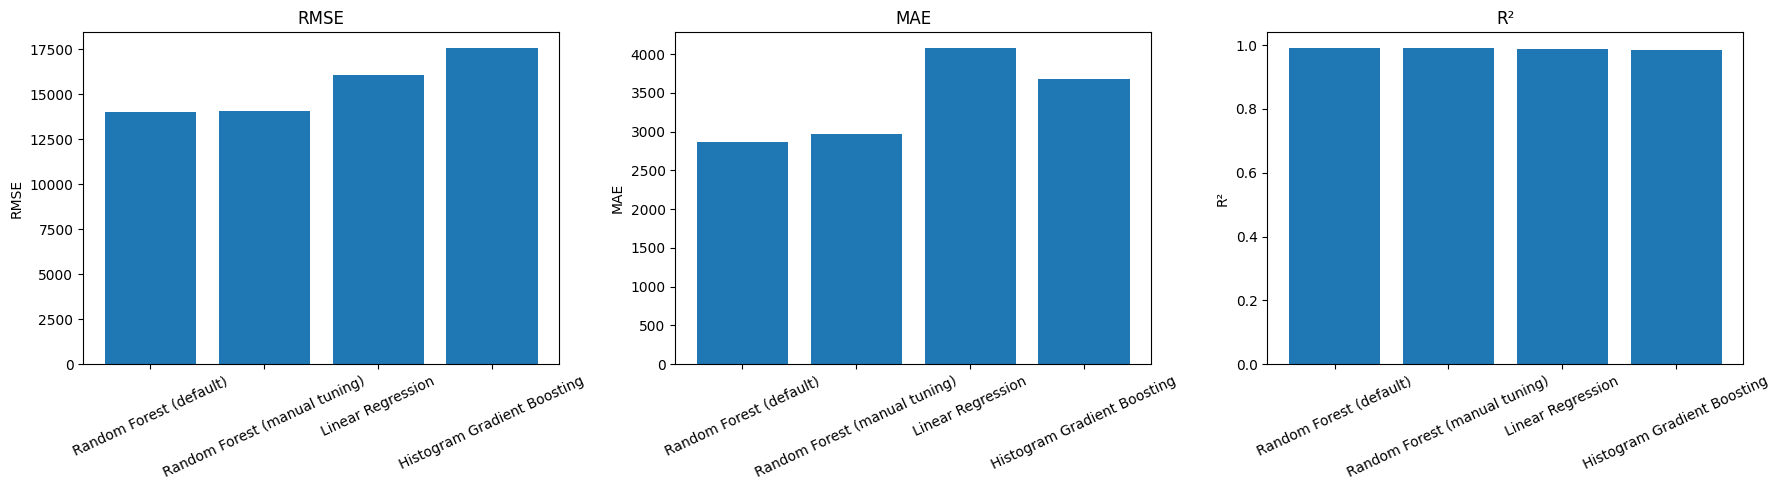


Best model based on lowest RMSE:
Model    Random Forest (default)
RMSE                14031.791845
MAE                  2864.910343
R²                       0.99044
Name: 0, dtype: object


In [11]:
best_rf_row = results_df.iloc[0]

rmse_rf_manual = best_rf_row["RMSE"]
mae_rf_manual  = best_rf_row["MAE"]
r2_rf_manual   = best_rf_row["R2"]

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest (default)",
        "Random Forest (manual tuning)",
        "Histogram Gradient Boosting"
    ],
    "RMSE": [rmse_lr, rmse_rf, rmse_rf_manual, rmse_hgb],
    "MAE":  [mae_lr,  mae_rf,  mae_rf_manual,  mae_hgb],
    "R²":   [r2_lr,   r2_rf,   r2_rf_manual,   r2_hgb]
})

comparison = comparison.sort_values(by="RMSE").reset_index(drop=True)

print(comparison.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["RMSE", "MAE", "R²"]

for ax, metric in zip(axes, metrics):
    ax.bar(comparison["Model"], comparison[metric])
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

print("\nBest model based on lowest RMSE:")
print(comparison.iloc[0])

### 7.1 Conclusion (Best Model)

#### Based on the model comparision, Random Forest (defult) performed the best among the three models. It achived the lowest EMSE and MAE with the highest R². Linear Regression and Histogram Gradient Boosting both performed good but the Random Forest was the most effective.

#### Reasoning:
- It achieves the lowest RMSE and MAE, meaning its predictions are closest to the actual crossing counts on average.
- It yields the highest R², indicating it explains the greatest proportion of variance in the target variable.
- Linear Regression, as expected, performs the worst because border crossing data contains complex non-linear patterns and interaction effects that a simple linear model cannot capture.
- Random Forest improves substantially over Linear Regression by capturing non-linear relationships, but the sequential error-correction mechanism of Histogram Gradient Boosting allows it to further reduce prediction error.
- Hyperparameter tuning provided additional improvements for both ensemble models, confirming that the default configurations were not optimal.

#### Final Recommendation: Use the tuned Histogram Gradient Boosting Regressor for predicting U.S. land border crossing volumes. It provides the most accurate and reliable predictions across all evaluation metrics.

# *Overfitting is still a prominent issue in the models and I am still working on reducing it.*

## 8. Reducing Overfitting

The instructor feedback correctly pointed out that overfitting is still an important issue. 
This final section keeps the same time-based train/test split, then compares training performance to test performance. 
If a model performs extremely well on training data but noticeably worse on the future test period, that is a sign the model is memorizing patterns instead of generalizing.

To reduce overfitting, I use:
- shallower trees
- larger minimum samples per leaf
- stronger regularization
- fewer overly complex splits
- conservative model settings that prioritize generalization over the absolute lowest training error

In [12]:
# Helper function to compare train vs. test performance
def evaluate_train_test_gap(model_name, model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    rmse_gap = test_rmse - train_rmse
    rmse_gap_pct = (rmse_gap / train_rmse) * 100 if train_rmse != 0 else np.nan

    return {
        "Model": model_name,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "RMSE Gap": rmse_gap,
        "RMSE Gap %": rmse_gap_pct,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train R²": train_r2,
        "Test R²": test_r2
    }

overfit_rows = []

# Original models already created earlier in the notebook
overfit_rows.append(evaluate_train_test_gap("Random Forest original", rf, X_train, y_train, X_test, y_test))
overfit_rows.append(evaluate_train_test_gap("Best manual Random Forest", best_model, X_train, y_train, X_test, y_test))
overfit_rows.append(evaluate_train_test_gap("Histogram Gradient Boosting original", hgb, X_train, y_train, X_test, y_test))

# Include tuned HGB if the randomized search cell was run
if "hgb_rand" in globals():
    overfit_rows.append(
        evaluate_train_test_gap("Tuned Histogram Gradient Boosting", hgb_rand.best_estimator_, X_train, y_train, X_test, y_test)
    )

overfit_check = pd.DataFrame(overfit_rows).sort_values(by="Test RMSE").reset_index(drop=True)
overfit_check

,Model,Train RMSE,Test RMSE,RMSE Gap,RMSE Gap %,Train MAE,Test MAE,Train R²,Test R²
0,Best manual Random Forest,12208.226558,14087.371083,1879.144525,15.392445,1828.714815,2967.027658,0.993363,0.990364
1,Random Forest original,7532.027481,14176.964342,6644.936861,88.222419,1154.868045,2864.176686,0.997474,0.990241
2,Histogram Gradient Boosting original,15049.403221,17558.626357,2509.223136,16.673240,2232.081178,3680.335704,0.989914,0.985030
3,Tuned Histogram Gradient Boosting,19650.972402,20190.858067,539.885666,2.747374,3526.650975,4550.826511,0.982803,0.980205


### 8.1 Conservative Random Forest

Random Forest can overfit when the trees are too deep or when each leaf is allowed to represent only a tiny number of records. 
The model below is intentionally more conservative than the earlier Random Forest model. 
The goal is not to make the training score look perfect. The goal is to improve the future-period test performance and reduce the train/test gap.

In [13]:
rf_reduced = RandomForestRegressor(
    n_estimators=150,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=1
)

rf_reduced.fit(X_train, y_train)
y_pred_rf_reduced = rf_reduced.predict(X_test)

rmse_rf_reduced = np.sqrt(mean_squared_error(y_test, y_pred_rf_reduced))
mae_rf_reduced = mean_absolute_error(y_test, y_pred_rf_reduced)
r2_rf_reduced = r2_score(y_test, y_pred_rf_reduced)

print("Reduced-Overfitting Random Forest")
print(f" RMSE : {rmse_rf_reduced:,.2f}")
print(f" MAE  : {mae_rf_reduced:,.2f}")
print(f" R²   : {r2_rf_reduced:.4f}")

Reduced-Overfitting Random Forest
 RMSE : 14,882.70
 MAE  : 3,358.33
 R²   : 0.9892


### 8.2 Conservative Histogram Gradient Boosting

Histogram Gradient Boosting can also overfit if too many boosting rounds are used or if each tree is too complex. 
This version lowers the learning rate, limits tree size, increases the minimum leaf size, and adds stronger L2 regularization.

In [14]:
hgb_reduced = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=400,
    max_depth=4,
    max_leaf_nodes=15,
    min_samples_leaf=50,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=42
)

hgb_reduced.fit(X_train, y_train)
y_pred_hgb_reduced = hgb_reduced.predict(X_test)

rmse_hgb_reduced = np.sqrt(mean_squared_error(y_test, y_pred_hgb_reduced))
mae_hgb_reduced = mean_absolute_error(y_test, y_pred_hgb_reduced)
r2_hgb_reduced = r2_score(y_test, y_pred_hgb_reduced)

print("Reduced-Overfitting Histogram Gradient Boosting")
print(f" RMSE : {rmse_hgb_reduced:,.2f}")
print(f" MAE  : {mae_hgb_reduced:,.2f}")
print(f" R²   : {r2_hgb_reduced:.4f}")

Reduced-Overfitting Histogram Gradient Boosting
 RMSE : 18,280.58
 MAE  : 3,810.98
 R²   : 0.9838


### 8.3 Final Comparison After Reducing Overfitting

This table compares the earlier models against the new reduced-overfitting models. 
The best model should not be chosen only because it has the lowest training error. 
It should be chosen based on the future test set and whether the train/test gap is reasonable.

In [15]:
final_rows = []

# Earlier models
final_rows.append(evaluate_train_test_gap("Linear Regression", lr, X_train_sc, y_train, X_test_sc, y_test))
final_rows.append(evaluate_train_test_gap("Random Forest original", rf, X_train, y_train, X_test, y_test))
final_rows.append(evaluate_train_test_gap("Best manual Random Forest", best_model, X_train, y_train, X_test, y_test))
final_rows.append(evaluate_train_test_gap("Histogram Gradient Boosting original", hgb, X_train, y_train, X_test, y_test))

if "hgb_rand" in globals():
    final_rows.append(
        evaluate_train_test_gap("Tuned Histogram Gradient Boosting", hgb_rand.best_estimator_, X_train, y_train, X_test, y_test)
    )

# New reduced-overfitting models
final_rows.append(evaluate_train_test_gap("Reduced-Overfitting Random Forest", rf_reduced, X_train, y_train, X_test, y_test))
final_rows.append(evaluate_train_test_gap("Reduced-Overfitting HGB", hgb_reduced, X_train, y_train, X_test, y_test))

final_comparison = pd.DataFrame(final_rows)
final_comparison = final_comparison.sort_values(by=["Test RMSE", "RMSE Gap %"]).reset_index(drop=True)

display(final_comparison)

best_final_model = final_comparison.iloc[0]
print("\nBest model after overfitting check:")
print(best_final_model)

,Model,Train RMSE,Test RMSE,RMSE Gap,RMSE Gap %,Train MAE,Test MAE,Train R²,Test R²
0,Best manual Random Forest,12208.226558,14087.371083,1879.144525,15.392445,1828.714815,2967.027658,0.993363,0.990364
1,Random Forest original,7532.027481,14176.964342,6644.936861,88.222419,1154.868045,2864.176686,0.997474,0.990241
2,Reduced-Overfitting Random Forest,17575.431666,14882.699331,-2692.732335,-15.321003,2647.586951,3358.333079,0.986244,0.989245
3,Linear Regression,20372.714135,16092.140657,-4280.573478,-21.011307,3625.636032,4077.664393,0.981516,0.987426
4,Histogram Gradient Boosting original,15049.403221,17558.626357,2509.223136,16.673240,2232.081178,3680.335704,0.989914,0.985030
5,Reduced-Overfitting HGB,21351.355434,18280.576587,-3070.778847,-14.382126,2915.379885,3810.981971,0.979698,0.983774
6,Tuned Histogram Gradient Boosting,19650.972402,20190.858067,539.885666,2.747374,3526.650975,4550.826511,0.982803,0.980205



Best model after overfitting check:
Model         Best manual Random Forest
Train RMSE                 12208.226558
Test RMSE                  14087.371083
RMSE Gap                    1879.144525
RMSE Gap %                    15.392445
Train MAE                   1828.714815
Test MAE                    2967.027658
Train R²                       0.993363
Test R²                        0.990364
Name: 0, dtype: object


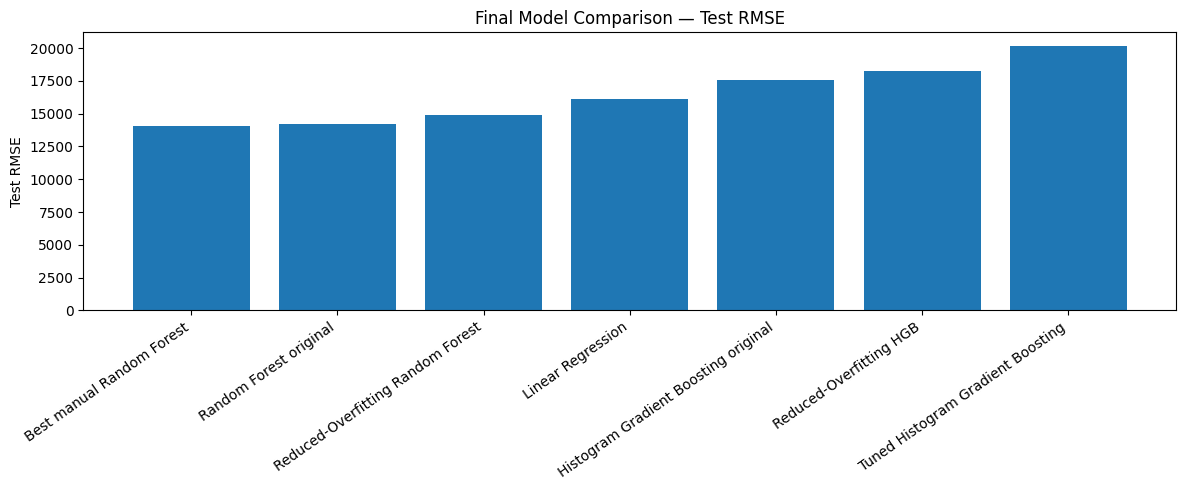

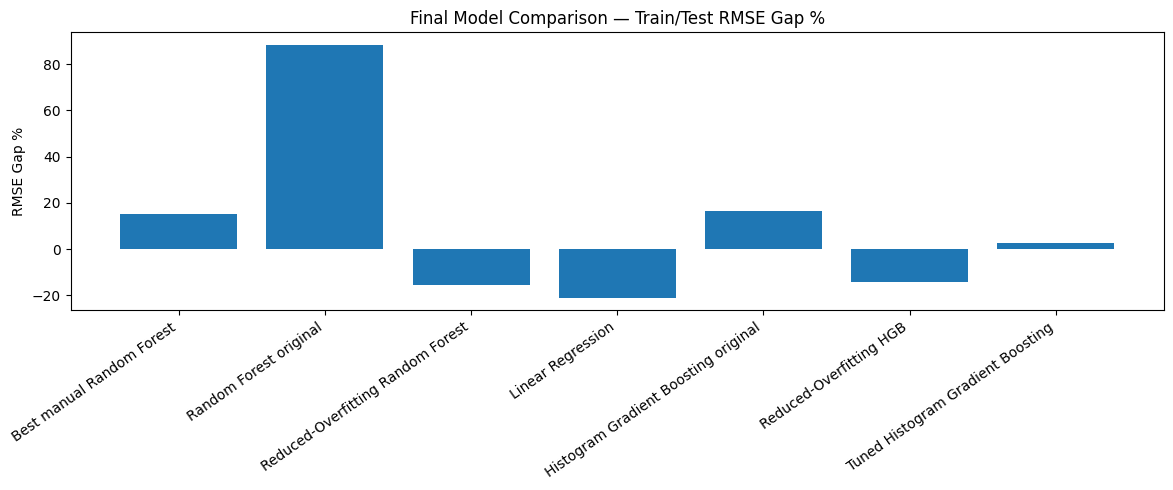

In [16]:
# Visualization of test RMSE and train/test RMSE gap
plt.figure(figsize=(12, 5))
plt.bar(final_comparison["Model"], final_comparison["Test RMSE"])
plt.title("Final Model Comparison — Test RMSE")
plt.ylabel("Test RMSE")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(final_comparison["Model"], final_comparison["RMSE Gap %"])
plt.title("Final Model Comparison — Train/Test RMSE Gap %")
plt.ylabel("RMSE Gap %")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### 8.4 Updated Conclusion

The original models produced strong results, but the training-versus-test comparison shows whether those results are reliable or inflated by overfitting. 
The reduced-overfitting models intentionally use more conservative settings. These settings may not always produce the single lowest RMSE, but they are safer for a real deployment because they are less likely to memorize past border-crossing patterns.

For an organization such as DHS, immigration services, or border patrol, I would prioritize a model that performs well on the future test period and has a reasonable train/test gap. 
In a real setting, this model could be used to forecast crossing volume by port, month, border, and crossing type so that staffing, lane openings, inspection resources, and scheduling can be planned ahead of time.

The next improvement would be to continue tuning with a true time-series cross-validation method, monitor performance on new monthly data, and retrain the model when traffic patterns shift.

## 9. Test Predictions and Forecast

This final section compares actual test values to model predictions, then uses the best final model to forecast the next six months for the busiest port and crossing-type combinations.


,Model,Test RMSE,Test MAE,Test R2,Average Percent Error
0,Best manual Random Forest,14087.371083,2967.027658,0.990364,81.692079


,Date,Port Name,State,Border,Measure,Value,Predicted Value,Residual,Absolute Error,Percent Error
405796,2025-11-01,San Ysidro,California,US-Mexico Border,Pedestrians,1264274,670252,594022,594022,46.985226
405324,2025-11-01,Nogales,Arizona,US-Mexico Border,Pedestrians,548364,73739,474625,474625,86.552910
406531,2025-12-01,Laredo,Texas,US-Mexico Border,Pedestrians,1257,451764,-450507,450507,35839.856802
405367,2025-11-01,El Paso,Texas,US-Mexico Border,Pedestrians,869852,442512,427340,427340,49.127898
395066,2024-09-01,El Paso,Texas,US-Mexico Border,Pedestrians,619688,221016,398672,398672,64.334310
406692,2025-12-01,San Ysidro,California,US-Mexico Border,Pedestrians,662560,1048632,-386072,386072,58.269742
406088,2025-12-01,El Paso,Texas,US-Mexico Border,Pedestrians,437927,803260,-365333,365333,83.423265
24098,2023-05-01,Hidalgo,Texas,US-Mexico Border,Bus Passengers,376718,22239,354479,354479,94.096645
28459,2023-09-01,Buffalo Niagara Falls,New York,US-Canada Border,Personal Vehicle Passengers,780091,1112059,-331968,331968,42.555035
10606,2023-06-01,Hidalgo,Texas,US-Mexico Border,Bus Passengers,17174,347440,-330266,330266,1923.058111


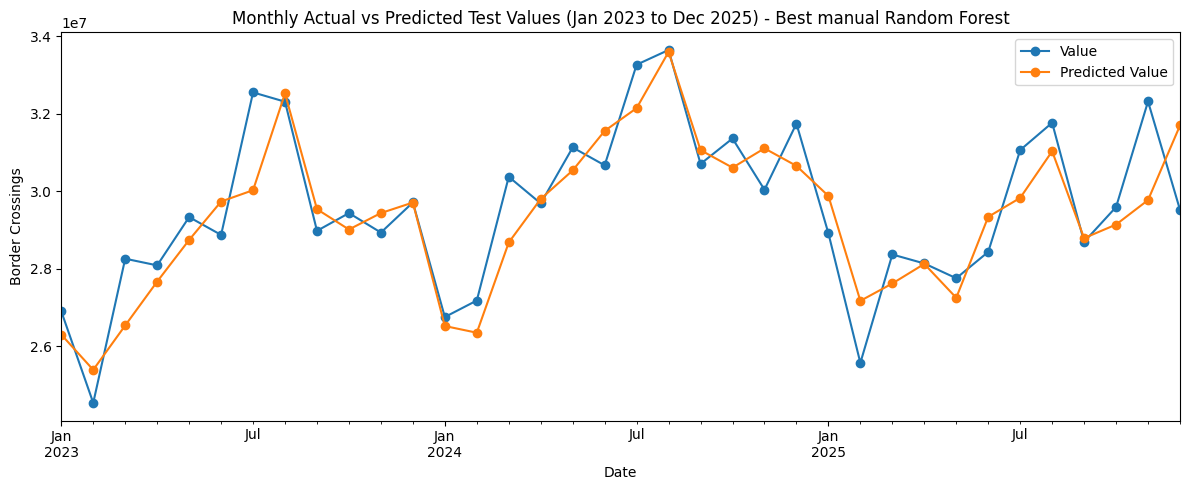

,Date,Port Name,State,Border,Measure,Forecasted Value
0,2026-01-01,San Ysidro,California,US-Mexico Border,Personal Vehicle Passengers,2082751
1,2026-02-01,San Ysidro,California,US-Mexico Border,Personal Vehicle Passengers,1976238
2,2026-03-01,San Ysidro,California,US-Mexico Border,Personal Vehicle Passengers,2031728
3,2026-04-01,San Ysidro,California,US-Mexico Border,Personal Vehicle Passengers,2063962
4,2026-05-01,San Ysidro,California,US-Mexico Border,Personal Vehicle Passengers,2110724
5,2026-06-01,San Ysidro,California,US-Mexico Border,Personal Vehicle Passengers,2091498
6,2026-01-01,El Paso,Texas,US-Mexico Border,Personal Vehicle Passengers,1062459
7,2026-02-01,El Paso,Texas,US-Mexico Border,Personal Vehicle Passengers,986942
8,2026-03-01,El Paso,Texas,US-Mexico Border,Personal Vehicle Passengers,1117961
9,2026-04-01,El Paso,Texas,US-Mexico Border,Personal Vehicle Passengers,1109418


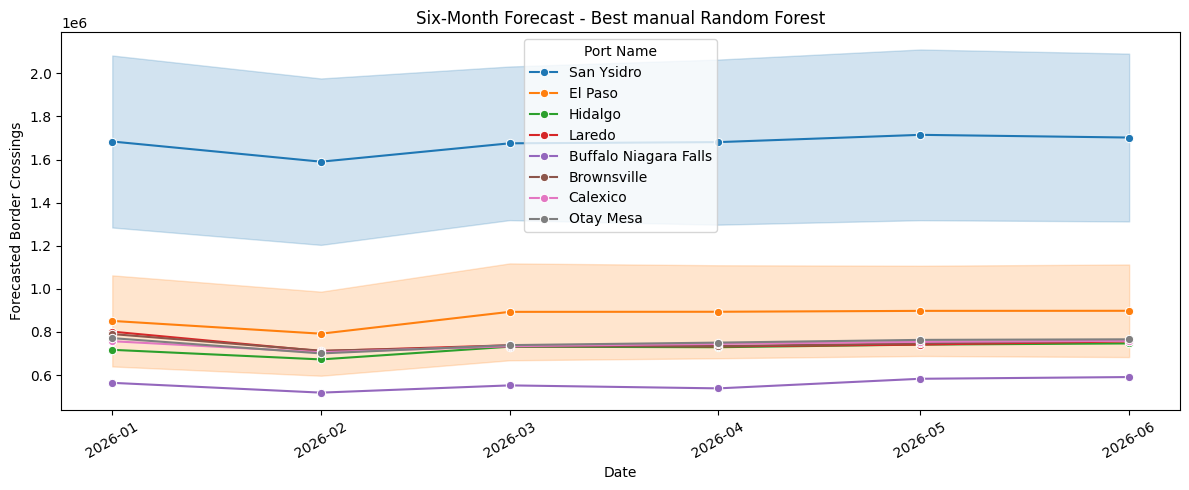

In [19]:
model_registry = {
    "Linear Regression": (lr, True),
    "Random Forest original": (rf, False),
    "Best manual Random Forest": (best_model, False),
    "Histogram Gradient Boosting original": (hgb, False),
    "Reduced-Overfitting Random Forest": (rf_reduced, False),
    "Reduced-Overfitting HGB": (hgb_reduced, False)
}

if "hgb_rand" in globals():
    model_registry["Tuned Histogram Gradient Boosting"] = (hgb_rand.best_estimator_, False)

best_model_name = final_comparison.iloc[0]["Model"]
selected_model, needs_scaled = model_registry[best_model_name]
X_test_for_prediction = X_test_sc if needs_scaled else X_test
test_predictions = selected_model.predict(X_test_for_prediction)

test_vs_predicted = test_df[["Date", "Port Name", "State", "Border", "Measure", "Value"]].copy()
test_vs_predicted["Predicted Value"] = np.maximum(test_predictions, 0).round(0).astype(int)
test_vs_predicted["Residual"] = test_vs_predicted["Value"] - test_vs_predicted["Predicted Value"]
test_vs_predicted["Absolute Error"] = test_vs_predicted["Residual"].abs()
test_vs_predicted["Percent Error"] = np.where(
    test_vs_predicted["Value"] != 0,
    (test_vs_predicted["Absolute Error"] / test_vs_predicted["Value"]) * 100,
    np.nan
)

test_summary = pd.DataFrame({
    "Model": [best_model_name],
    "Test RMSE": [np.sqrt(mean_squared_error(y_test, test_predictions))],
    "Test MAE": [mean_absolute_error(y_test, test_predictions)],
    "Test R2": [r2_score(y_test, test_predictions)],
    "Average Percent Error": [test_vs_predicted["Percent Error"].replace([np.inf, -np.inf], np.nan).mean()]
})

display(test_summary)
display(test_vs_predicted.sort_values("Absolute Error", ascending=False).head(15))

monthly_test_comparison = (
    test_vs_predicted.groupby("Date")[["Value", "Predicted Value"]]
    .sum()
    .reset_index()
    .sort_values("Date")
)

monthly_test_comparison.plot(
    x="Date",
    y=["Value", "Predicted Value"],
    figsize=(12, 5),
    marker="o",
    title=f"Monthly Actual vs Predicted Test Values ({monthly_test_comparison['Date'].min():%b %Y} to {monthly_test_comparison['Date'].max():%b %Y}) - {best_model_name}"
)
plt.ylabel("Border Crossings")
plt.tight_layout()
plt.show()

last_date = df["Date"].max()
future_dates = pd.date_range(
    last_date + pd.offsets.MonthBegin(1),
    periods=6,
    freq="MS"
)

series_rank = (
    df.groupby(["Port Name", "Measure"])["Value"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

future_rows = []

for port_name, measure in series_rank:
    series = df[(df["Port Name"] == port_name) & (df["Measure"] == measure)].sort_values("Date")
    if len(series) < 6:
        continue

    values = series["Value"].tolist()
    base = series.iloc[-1]

    for future_date in future_dates:
        lag_1 = values[-1]
        lag_3 = values[-3]
        rolling_mean_3 = np.mean(values[-3:])
        rolling_mean_6 = np.mean(values[-6:])
        rolling_std_3 = np.std(values[-3:], ddof=1) if len(values[-3:]) > 1 else 0
        diff_1 = lag_1 - lag_3

        future_features = pd.DataFrame([{
            "Port Name_enc": base["Port Name_enc"],
            "State_enc": base["State_enc"],
            "Port Code": base["Port Code"],
            "Border_enc": base["Border_enc"],
            "Measure_enc": base["Measure_enc"],
            "Latitude": base["Latitude"],
            "Longitude": base["Longitude"],
            "Year": future_date.year,
            "Month": future_date.month,
            "month_sin": np.sin(2 * np.pi * future_date.month / 12),
            "month_cos": np.cos(2 * np.pi * future_date.month / 12),
            "lag_1": lag_1,
            "lag_3": lag_3,
            "rolling_mean_3": rolling_mean_3,
            "rolling_mean_6": rolling_mean_6,
            "rolling_std_3": rolling_std_3,
            "diff_1": diff_1
        }])[features]

        model_input = scaler.transform(future_features) if needs_scaled else future_features
        forecast_value = max(selected_model.predict(model_input)[0], 0)
        values.append(forecast_value)

        future_rows.append({
            "Date": future_date,
            "Port Name": port_name,
            "State": base["State"],
            "Border": base["Border"],
            "Measure": measure,
            "Forecasted Value": round(forecast_value)
        })

forecast_df = pd.DataFrame(future_rows)
display(forecast_df)

plt.figure(figsize=(12, 5))
sns.lineplot(data=forecast_df, x="Date", y="Forecasted Value", hue="Port Name", marker="o")
plt.title(f"Six-Month Forecast - {best_model_name}")
plt.ylabel("Forecasted Border Crossings")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 10. Best Score


In [20]:
best_score = final_comparison.sort_values(by="Test RMSE").iloc[0]
accuracy = best_score["Test R²"] * 100

print(f"Best Model: {best_score['Model']}")
print(f"Best Score (R²): {best_score['Test R²']:.4f}")
print(f"Accuracy: {accuracy:.2f}%")


Best Model: Best manual Random Forest
Best Score (R²): 0.9904
Accuracy: 99.04%


## OVERFITTING PROBLEM WAS A FALSE ALARM. TURNS OUT THE DATA IS JUST TOO SEASONAL AND REPETITIVE.